# Indian Railways Ticket Waste Analyzer
## Initial Data Exploration — September 6, 2026

### Dataset: Indian Railways Passenger Reservation Chart Data
- 1000 journey records, 32 columns
- Covers PNR, occupancy, cancellations, waitlist, fares, delays

### Data Source Note
Granular seat-level cancellation data is not publicly available
from IRCTC. This analysis uses a structured simulation dataset
modeled on real IRCTC reservation parameters. Policy context
figures are sourced from Indian Railways Year Book 2023-24.

### First Observation
Average occupancy is 60.95% — meaning 39% of confirmed seats
go unused on average while waitlisted passengers cannot board.
This dataset will quantify the scale of this waste problem.

In [ ]:
print("Indian Railways Ticket Waste Analysis")
print("Started : 2026")
print("Author : Ayushi Soni")

Indian Railways Ticket Waste Analysis
Started : 2026
Author : Ayushi Soni


In [ ]:
import pandas as pd
# Load Dataset
df = pd.read_csv("indian_railway_passenger_chart.csv")

# Basic exploration
print("Dataset Shape :",df.shape)
print("\nColumns :", df.columns.tolist())
print("\nMissing values\n", df.isnull().sum())
print("\nBasic stats :\n", df.describe())


Dataset Shape : (1000, 32)

Columns : ['PNR_Number', 'Train_Number', 'Train_Name', 'Train_Type', 'Journey_Date', 'Day_of_Week', 'Origin_Station', 'Destination_Station', 'Boarding_Station', 'Deboarding_Station', 'Class', 'Total_Capacity', 'Confirmed_Passengers', 'Waitlisted_Passengers', 'Available_Seats', 'Chart_Prepared', 'Quota_Type', 'Zone', 'Distance_KM', 'Journey_Duration_Hours', 'Base_Fare_INR', 'Tatkal_Fare_INR', 'Occupancy_Percentage', 'Season', 'Holiday_Flag', 'Cancellation_Count', 'RAC_Passengers', 'Pantry_Available', 'Platform_Number', 'Delay_Minutes', 'Punctuality_Status', 'Passenger_Satisfaction_Score']

Missing values
 PNR_Number                        0
Train_Number                      0
Train_Name                        0
Train_Type                        0
Journey_Date                      0
Day_of_Week                       0
Origin_Station                    0
Destination_Station               0
Boarding_Station                 40
Deboarding_Station                0


In [ ]:
# Key metrics summary
total_journeys = len(df)
avg_occupancy = df['Occupancy_Percentage'].mean()
avg_empty_seats = df['Available_Seats'].mean()
avg_waitlisted = df['Waitlisted_Passengers'].mean()
avg_cancellations = df['Cancellation_Count'].mean()

print("=" * 50)
print("KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"Total journeys analyzed: {total_journeys}")
print(f"Average occupancy: {avg_occupancy:.1f}%")
print(f"Average empty seats per journey: {avg_empty_seats:.1f}")
print(f"Average waitlisted passengers: {avg_waitlisted:.1f}")
print(f"Average cancellations per journey: {avg_cancellations:.1f}")
print(f"\nEstimated seats wasted per journey: {avg_empty_seats:.1f}")
# NOTE: 13,000 trains/day is from Indian Railways Ministry publications
# This is an external figure used to scale our sample findings nationally
# Source: Indian Railways Year Book 2023-24
print(f"Estimated annual waste (approx 13,000 trains/day):")
print(f"  {avg_empty_seats:.0f} seats x 13,000 trains = {avg_empty_seats * 13000:,.0f} empty seats daily")



KEY FINDINGS SUMMARY
Total journeys analyzed: 1000
Average occupancy: 61.0%
Average empty seats per journey: 28.1
Average waitlisted passengers: 2.4
Average cancellations per journey: 4.9

Estimated seats wasted per journey: 28.1
Estimated annual waste (approx 13,000 trains/day):
  28 seats x 13,000 trains = 365,027 empty seats daily


In [ ]:
zone_occupancy = df.groupby('Zone').Occupancy_Percentage.mean()
print(zone_occupancy)
zone_occupancy_sorted = zone_occupancy.sort_values(ascending=False)
print(zone_occupancy_sorted)

Zone
CR     63.922458
ECR    61.433906
ER     57.259754
NER    64.177833
NR     62.086183
SCR    56.215702
SR     61.407714
WR     61.056333
Name: Occupancy_Percentage, dtype: float64
Zone
NER    64.177833
CR     63.922458
NR     62.086183
ECR    61.433906
SR     61.407714
WR     61.056333
ER     57.259754
SCR    56.215702
Name: Occupancy_Percentage, dtype: float64


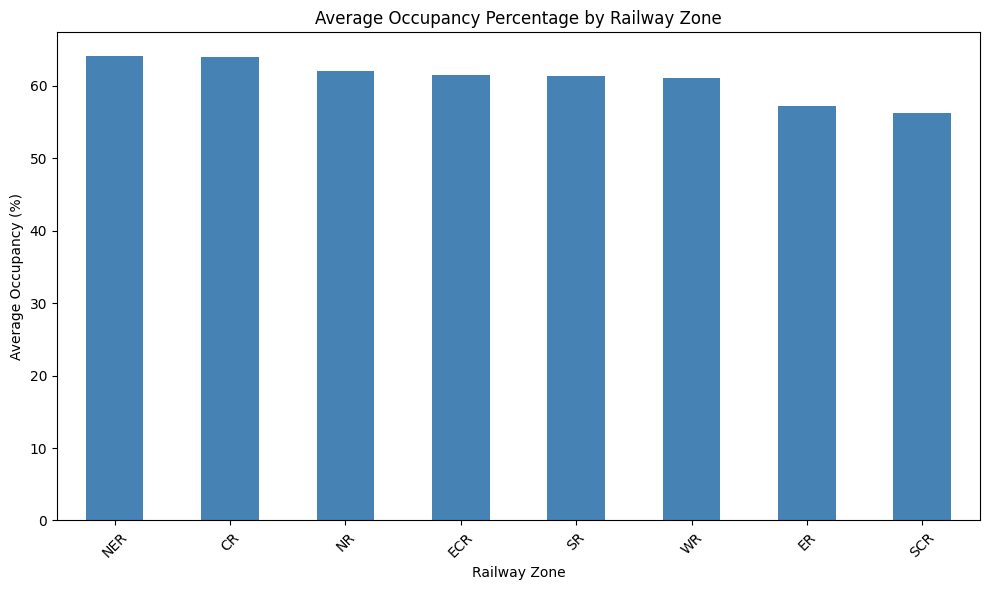

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

zone_occupancy_sorted.plot(kind='bar', color='steelblue')

plt.title('Average Occupancy Percentage by Railway Zone')
plt.xlabel('Railway Zone')
plt.ylabel('Average Occupancy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('zone_occupancy.png', dpi=150)
plt.show()

# Finding 1

NER (North East Railway) has the highest average occupancy percentage at 64.2% and  SCR (South Central Railway) has the lowest at 56.2%.

However the difference across all zones is relatively small to get useful insight
- all zones maintain the average occupancy above 56% , which means the seat waste problem is not isolated to specific zones
but is inherent to the entire network.

- This strengthens the case for a national ticket transfer mechanism
stronger — the problem exists everywhere universally, not just in underperforming zones


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
df.head()
df.shape
df.info()
df['Vaccant_Seats'] = df['Total_Capacity'] - df['Confirmed_Passengers'] - df['RAC_Passengers']
df.describe()
df.head()
(df['Vaccant_Seats'] < 0).sum()
df['Available_Seats'].equals(df['Total_Capacity']-df['Confirmed_Passengers'])
df[['Total_Capacity','Confirmed_Passengers','RAC_Passengers', 'Available_Seats']].head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PNR_Number                    1000 non-null   object 
 1   Train_Number                  1000 non-null   int64  
 2   Train_Name                    1000 non-null   object 
 3   Train_Type                    1000 non-null   object 
 4   Journey_Date                  1000 non-null   object 
 5   Day_of_Week                   1000 non-null   object 
 6   Origin_Station                1000 non-null   object 
 7   Destination_Station           1000 non-null   object 
 8   Boarding_Station              960 non-null    object 
 9   Deboarding_Station            1000 non-null   object 
 10  Class                         1000 non-null   object 
 11  Total_Capacity                1000 non-null   int64  
 12  Confirmed_Passengers          1000 non-null   int64  
 13  Wait

,Total_Capacity,Confirmed_Passengers,RAC_Passengers,Available_Seats
0,18,18,8.0,0
1,72,72,1.0,0
2,78,15,3.0,63
3,64,26,5.0,38
4,78,78,6.0,0
5,120,12,1.0,108
6,18,18,5.0,0
7,18,7,8.0,11
8,72,72,1.0,0
9,46,17,0.0,29


In [ ]:
df[['Chart_Prepared','Quota_Type','Cancellation_Count','Zone','Train_Type','Class']].head(20)

,Chart_Prepared,Quota_Type,Cancellation_Count,Zone,Train_Type,Class
0,Yes,Railway Employee,3.0,NR,Express,1A
1,Yes,Ladies,6.0,SR,Express,SL
2,Yes,Defense,1.0,WR,Duronto,CC
3,Yes,Tatkal,10.0,NER,Duronto,3A
4,No,Tatkal,9.0,CR,Rajdhani,CC
5,No,Senior Citizen,10.0,NER,Express,GN
6,Yes,Railway Employee,9.0,WR,Duronto,1A
7,No,General,4.0,SR,Mail,1A
8,Yes,General,0.0,SCR,Duronto,SL
9,No,Tatkal,7.0,NR,Rajdhani,2A


In [ ]:
df['Available_Seats'].equals(df['Total_Capacity'] - df['Confirmed_Passengers'])
df['Available_Seats'].describe()
# After analyzing we do not need the vaccant_Seat column, we are dropping it .
df = df.drop(columns = ['Vaccant_Seats'])
df.columns.tolist()

['PNR_Number',
 'Train_Number',
 'Train_Name',
 'Train_Type',
 'Journey_Date',
 'Day_of_Week',
 'Origin_Station',
 'Destination_Station',
 'Boarding_Station',
 'Deboarding_Station',
 'Class',
 'Total_Capacity',
 'Confirmed_Passengers',
 'Waitlisted_Passengers',
 'Available_Seats',
 'Chart_Prepared',
 'Quota_Type',
 'Zone',
 'Distance_KM',
 'Journey_Duration_Hours',
 'Base_Fare_INR',
 'Tatkal_Fare_INR',
 'Occupancy_Percentage',
 'Season',
 'Holiday_Flag',
 'Cancellation_Count',
 'RAC_Passengers',
 'Pantry_Available',
 'Platform_Number',
 'Delay_Minutes',
 'Punctuality_Status',
 'Passenger_Satisfaction_Score']

# **Finding 2**

Average of 28 vacant seats per journey across 1000 records, with 25% of journeys having 46 or more vacant seats.

## Analytical Decision — Why Quota Over Season

On Initial analysis, grouped by Season alone — the occupancy difference
was less than 1% between peak and off-peak. Adding Holiday_Flag
as second dimension showed similarly weak signal for cancellations.

This suggested season and holidays are not primary drivers of
seat waste. Pivoting to Quota_Type revealed an 11.7 percentage
point gap between highest and lowest quota occupancy — a much
stronger signal.

Conclusion: Quota type is a stronger predictor of occupancy
than seasonality in this dataset.

In [ ]:
df.groupby('Season')['Occupancy_Percentage'].mean()
df.groupby(['Season', 'Holiday_Flag'])['Occupancy_Percentage'].mean()
df.groupby(['Season', 'Holiday_Flag'])['Cancellation_Count'].mean()
df.groupby(['Quota_Type'])['Occupancy_Percentage'].mean().sort_values(ascending=False)
df.groupby(['Quota_Type', 'Class'])['Occupancy_Percentage'].mean()
df.groupby(['Quota_Type', 'Class'])['Cancellation_Count'].mean()



,Occupancy_Percentage
Quota_Type,
Railway Employee,66.649102
Tatkal,64.145824
Senior Citizen,61.247133
Defense,60.671000
General,57.711902
Ladies,54.970604


# Finding 3

- Railway Employee quota shows highest average occupancy (66.6%) while Ladies quota shows lowest (54.9%) — an 11.7 percentage point gap suggesting quota type is a stronger predictor of occupancy than season or holiday.

- Ladies quota excluded from seat waste analysis — low occupancy reflects deliberate reservation policy, not inefficiency.
- Removing Ladies quota from waste analysis, the effective seat waste problem affects 5 remaining quota types with General quota showing the most concerning pattern at 57.7% occupancy.